# $$ \textbf{Sinais e Sistemas Dinâmicos}$$

## $$ 2^a \textbf{Avaliação - 02 de outubro de 2024}$$

### Nome:

In [5]:
## Importação das bibliotecas Python, como indicado no texto ##

# biblioteca Python para matemática simbólica 
import sympy as sp
from sympy import * 

# Pacote para computação científica
import numpy as np

# biblioteca para a visualização de dados em Python.
import matplotlib.pyplot as plt

# Este módulo fornece acesso às funções matemáticas (definidas pelo padrão C)
import math

# cmath permite operações com números complexos
import cmath

# O módulo de frações fornece suporte para aritmética de números racionais
from fractions import Fraction

# permite usar latex para exibir equações matemáticas no Jupyter Notebook
from IPython.display import display, Math

## Questão 1: 
Um sinal periódico de tempo contínuo $x(t)$ tem valor real e período fundamental $T=8$. Os coeficientes diferentes de zero da série de Fourier de $x(t)$ são

$$
a_1=a_{-1}=2, a_3=a_{-3}^*=4 j
$$


Expresse $x(t)$ na forma

$$
x(t)=\sum_{k=0}^{\infty} A_k \cos \left(\omega k t+\phi_k\right)
$$


### Solução:

In [3]:
t, a1, a3, phi1, phi3, T = symbols('t, a1, a3, phi1, phi3, T')
T = 8
w = 2*pi/T
x = 2*exp(-1J*w*t) + 2*exp(1J*w*t) - 4J*exp(-3J*w*t) + 4J*exp(3J*w*t)
x.rewrite(cos).simplify().rewrite(cos)

4.0*cos(pi*t/4) - 8.0*cos(0.75*pi*t - pi/2)

como $A_k \geq 0$, temos 

$$
x(t) = 4.0 \cos\left(\frac{\pi t}{4}\right) + 8.0 \cos\left(3\frac{ \pi t}{4} + \frac{\pi}{2}\right)
$$

Onde identificamos:

- $A_1 = 4.0$
- $A_3 = 8.0$
- $\phi_1 = 0.0$
- $\phi_3 = \frac{\pi}{2}$


## Questão 2: 
Determine as representações em série de Fourier para os seguintes sinais:


###### (a) $x(t)$ periódico com período 2 e

$$
x(t)=e^{-t}, \text { para }-1<t<1
$$
##### (b) $x(t)$ periódico com período 4 e

$$
x(t)= \begin{cases}\operatorname{sen} \pi t, & 0 \leq t \leq 2 \\ 0, & 2<t \leq 4\end{cases}
$$


### Solução:

**(a)** 

In [4]:
# Definir a variável de tempo
t = sp.symbols('t')

# Definir a função x(t) = e^(-t) para -1 < t < 1
x = sp.Piecewise((sp.exp(-t), (t > -1) & (t < 1)), (0, True))

# Aplicar a série de Fourier para tornar a função periódica com período 2
fourier_series = sp.fourier_series(x, (t, -1, 1))

# Truncar a série de Fourier (primeiros 5 termos)
x_t_periodic = fourier_series.truncate(5)

# Mostrar a função periódica truncada
fourier_series


FourierSeries(Piecewise((exp(-t), (t > -1) & (t < 1)), (0, True)), (t, -1, 1), (-exp(-1)/2 + E/2, SeqFormula((_n*pi*sin(_n*pi)/(_n**2*pi**2*exp(-1) + exp(-1)) + _n*pi*sin(_n*pi)/(_n**2*E*pi**2 + E) + cos(_n*pi)/(_n**2*pi**2*exp(-1) + exp(-1)) - cos(_n*pi)/(_n**2*E*pi**2 + E))*cos(_n*pi*t), (_n, 1, oo)), SeqFormula((_n*pi*cos(_n*pi)/(_n**2*pi**2*exp(-1) + exp(-1)) - _n*pi*cos(_n*pi)/(_n**2*E*pi**2 + E) - sin(_n*pi)/(_n**2*pi**2*exp(-1) + exp(-1)) - sin(_n*pi)/(_n**2*E*pi**2 + E))*sin(_n*pi*t), (_n, 1, oo))))

In [180]:
#n = symbols('n', integer = True)
#(1/4)*integrate(sin(pi*t)*exp(-1J*n*pi*t/2),(t,0,2))#.rewrite(sin)

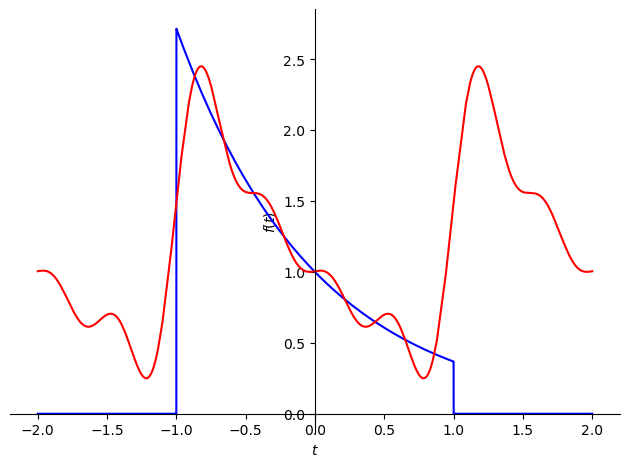

In [47]:
p1 = sp.plot(x, x_t_periodic, (t, -2, 2), show=False)

p1[0].line_color = 'b'
p1[1].line_color = 'r'
#p1[0].label = '$g(t)$'
p1.show()

**(b)** 

In [166]:
# Definir a variável de tempo
t = sp.symbols('t')

# Definir a função x(t) = sin(\pi t) para 0 < t < 2
x = sp.Piecewise((sp.sin(pi*t), (t > 0) & (t < 2)),(0, (t > 2) & (t < 4)), (0, True))

# Aplicar a série de Fourier para tornar a função periódica com período 4
fourier_series = sp.fourier_series(x, (t, 0, 4))

# Truncar a série de Fourier (primeiros 5 termos)
x_t_periodic = fourier_series.truncate(5)

# Mostrar a função periódica truncada
fourier_series

FourierSeries(Piecewise((sin(pi*t), (t > 0) & (t < 2)), (0, True)), (t, 0, 4), (0, SeqFormula(Piecewise((0, Eq(_n, -2) | Eq(_n, 2)), (4*cos(_n*pi)/(_n**2*pi - 4*pi) - 4/(_n**2*pi - 4*pi), True))*cos(_n*pi*t/2)/2, (_n, 1, oo)), SeqFormula(Piecewise((-1, Eq(_n, -2)), (1, Eq(_n, 2)), (4*sin(_n*pi)/(_n**2*pi - 4*pi), True))*sin(_n*pi*t/2)/2, (_n, 1, oo))))

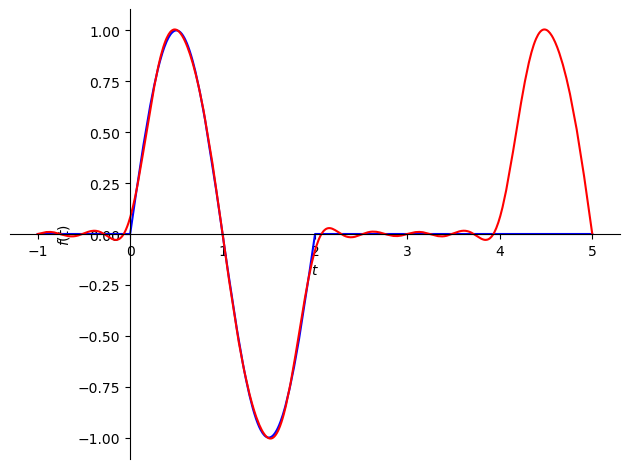

In [55]:
p1 = sp.plot(x, x_t_periodic, (t, -1, 5), show=False)

p1[0].line_color = 'b'
p1[1].line_color = 'r'
#p1[0].label = '$g(t)$'
p1.show()

## Questão 3: 
Um sinal $x(t)$ pode ser descrito pela soma de componentes par e ímpar:

$$
x(t)=x_e(t)+x_o(t)
$$

##### (a) se $x(t) \Leftrightarrow X(\omega)$, mostre que para $x(t)$ real,

$$
x_e(t) \Longleftrightarrow \operatorname{Re}[X(\omega)]
$$

e

$$
x_o(t) \Longleftrightarrow j \operatorname{Im}[X(\omega)]
$$

##### (b) Verifique esses resultados obtendo a transformada de Fourier das componentes par e ímpar dos seguintes sinais 

- (i) $u(t)$ e

- (ii) $e^{-a t} u(t)$.

### Solução:

**(a)** Vamos considerar duas propriedades da Série de Fourier:

- A propriedade do conjugado:

$$
x^*(t) \Longleftrightarrow X^*(-\omega)
$$


Basta tomar os conjugados dos dois lados da equação


$$
X(-\omega)=\int_{-\infty}^{\infty} x(t) e^{j \omega t} d t,
$$

Note que se $x(t)$ for uma função real de $t$, então $x(t)=x^*(t)$ e da propriedade do conjugado, temos que

$$
X(-\omega)=X^*(\omega).
$$

 - A Propriedade de Escalamento
 
Se

$$
x(t) \Longleftrightarrow X(\omega)
$$

então, para qualquer constante real $a$,

$$
x(a t) \Longleftrightarrow \frac{1}{|a|} X\left(\frac{\omega}{a}\right)
$$


Assim, 
$$
x(t)=x_e(t)+x_o(t) = 0.5\left(x(t) + x(-t) \right) + 0.5\left(x(t) - x(-t) \right)
$$

Como 

$$
x(t) \Leftrightarrow X(\omega),
$$
temos que (tomando $a = -1$ na propriedade do escalamento)

$$
x_e(t) = 0.5\left(x(t) + x(-t) \right) \Leftrightarrow 0.5\left( X(\omega) + X(- \omega)\right) \Leftrightarrow 0.5\left( X(\omega) + X^*(\omega)\right) = \operatorname{Re}[X(\omega)].
$$

Analogamente, 

$$
x_o(t) = 0.5\left(x(t) - x(-t) \right) \Leftrightarrow 0.5\left( X(\omega) - X(- \omega)\right) \Leftrightarrow 0.5\left( X(\omega) - X^*(\omega)\right) = j \operatorname{Im}[X(\omega)].
$$

**(b)** 


- (i) $u(t)$ e

- (ii) $e^{-a t} u(t)$.

Notemos que a transformada de Fourier do sinal $u(t)$, não pode ser calculada diretamente. De fato, temos que

In [164]:
t, w = sp.symbols('t, w')
u = Heaviside(t)
F = sp.fourier_transform(u, t, w, noconds=False).doit().rewrite(Integral)
F

Integral(exp(-2*I*pi*t*w)*Heaviside(t), (t, -oo, oo))

Uma alternativa é reescrever 
$$
u(t)=\lim _{a \rightarrow 0} e^{-a t} u(t).
$$

Assim, temos que
$$
U(\omega)=\lim _{a \rightarrow 0} \mathcal{F}\left\{e^{-a t} u(t)\right\}=\lim _{a \rightarrow 0} \frac{1}{a+j \omega}
$$
Expressando o lado direito em termos de sua parte real e imaginária resulta em
$$
\begin{aligned}
U(\omega) & =\lim _{a \rightarrow 0}\left[\frac{a}{a^2+\omega^2}-j \frac{\omega}{a^2+\omega^2}\right] \\
& =\lim _{a \rightarrow 0}\left[\frac{a}{a^2+\omega^2}\right]+\frac{1}{j \omega}\\
& =\pi \delta(\omega)+\frac{1}{j \omega}
\end{aligned}
$$

(i) Podemos observar, neste caso que
$$
u_e(t) = 0.5, \forall t \in \mathbb{R},
$$
e que 
$$
u_o(t) = 0.5sgn(t), \quad \text{onde } \quad sgn = \begin{cases} 1, \quad \text{se } t \geq 0\\ -1, \quad \text{se } t < 0 \end{cases}. 
$$
Devemos notar ainda que $\operatorname{sgn}(t)=2 u(t)-1$. Assim
$$
u_o(t) = 0.5sgn(t) = u(t)- 0.5. 
$$

Da transformada de Fourier inversa de $\delta(\omega)$, temos

$$
\mathcal{F}^{-1}[\delta(\omega)]=\frac{1}{2 \pi} \int_{-\infty}^{\infty} \delta(\omega) e^{j \omega t} d \omega=\frac{1}{2 \pi}
$$


Portanto,
$$
1 \Longleftrightarrow 2 \pi \delta(\omega),
$$
de onde, 

$$
u_e(t) = 0.5 \Longleftrightarrow  \pi \delta(\omega),
$$

e, 

$$
\begin{aligned}
u_o(t) & = 0.5sgn(t) \\
& = u(t)- 0.5 \Longleftrightarrow  \pi \delta(\omega)+\frac{1}{j \omega} -\pi \delta(\omega) \\
& = \frac{1}{j \omega}.
\end{aligned}
$$

Logo, 
$$
X_e(\omega)=\pi \delta(\omega) \quad \text { e } \quad X_o(\omega)=\frac{1}{j \omega}
$$

(ii) Para este caso, temos que
$$
e^{-a t} u(t)=\underbrace{\frac{1}{2}\left[e^{-a t} u(t)+e^{-a t} u(-t)\right]}_{x_e(t)}+\underbrace{\frac{1}{2}\left[e^{-a t} u(t)-e^{-a t} u(-t)\right]}_{x_o(t)}.
$$
Assim, 
$$
X_e(\omega)=\frac{1}{2}\left[\frac{1}{j \omega+a}-\frac{1}{j \omega-a}\right]=\frac{2 a}{\omega^2+a^2}
$$
e
$$
X_o(\omega)=\frac{1}{2}\left[\frac{1}{j \omega+a}+\frac{1}{j \omega-a}\right]=\frac{2 j \omega}{\omega^2+a^2}
$$

## Questão 4: 
A partir da definição, obtenha as transformadas de Fourier dos sinais mostrados na figura abaixo.

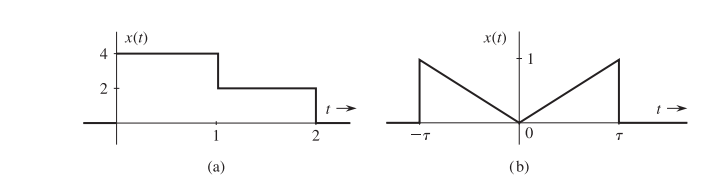

### Solução:

**(a)** 
$$
x(t)  = \begin{cases} 4, \quad 0 < t < 1,\\
                      2, \quad 1 < t < 2, \\
                      0, \quad \text{em caso contrário}
        \end{cases}
$$

$$X(\omega)=\int_0^1 4 e^{-j \omega t} d t+\int_1^2 2 e^{-j \omega t} d t=\frac{4-2 e^{-j \omega}-2 e^{-j 2 \omega}}{j \omega}$$

In [144]:
t, w = sp.symbols('t, w', real = True, nonzero = True)
simplify(integrate(4*exp(-1J*w*t),(t,0,1)) + integrate(2*exp(-1J*w*t),(t,1,2)))

-4.0*I/w + 2.0*I*exp(-2.0*I*w)/w + 2.0*I*exp(-1.0*I*w)/w

**(b)** 
$$
x(t)  = \begin{cases} -t/\tau, \quad -\tau < t < 0,\\
                      t/\tau, \quad 0 < t < \tau, \\
                      0, \quad \text{em caso contrário}
        \end{cases}
$$

$$
X(\omega)=\int_{-\tau}^0-\frac{t}{\tau} e^{-j \omega t} d t+\int_0^\tau \frac{t}{\tau} e^{-j \omega t} d t=\frac{2}{\tau \omega^2}[\cos \omega \tau+\omega \tau \sin \omega \tau-1]
$$

In [160]:
t, w, tau = sp.symbols('t, w, tau', real = True, nonzero = True)
simplify(integrate((-t/tau)*exp(-1J*w*t),(t,-tau,0)) + integrate((t/tau)*exp(-1J*w*t),(t,0,tau)))

(1.0*I*tau*w + (1.0*(-I*tau*w + 1)*exp(1.0*I*tau*w) - 2.0)*exp(1.0*I*tau*w) + 1.0)*exp(-1.0*I*tau*w)/(tau*w**2)

## Questão 5: 
A partir da definição, obtenha as transformadas de Fourier inversas do espectro da figura abaixo

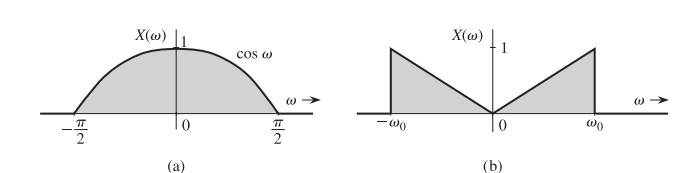

### Solução:

**(a)** 
$$
\begin{aligned}
x(t) & =\frac{1}{2 \pi} \int_{-\pi / 2}^{\pi / 2} \cos \omega e^{j \omega t} d \omega \\
& =\left.\frac{e^{j \omega t}}{2 \pi\left(1-t^2\right)}(j t \cos \omega+\sin \omega)\right|_{-\pi / 2} ^{\pi / 2} \\
& =\frac{1}{\pi\left(1-t^2\right)} \cos \left(\frac{\pi t}{2}\right)
\end{aligned}
$$

In [161]:
t, w = sp.symbols('t, w', real = True, nonzero = True)
simplify(integrate(cos(w)*exp(1J*w*t),(w,-pi/2,pi/2))/(2*pi))

Piecewise((0.25, Eq(t, -1.0) | Eq(t, 1.0)), (-1.0*cos(pi*t/2)/(pi*(t**2 - 1)), True))

**(b)** 

$$
\begin{aligned}
x(t) & = \frac{1}{2 \pi} \int_{-w_0}^{w_0} X(\omega) e^{j \omega t} \, d\omega \\
     & = \frac{1}{2 \pi} \left[ \int_{-w_0}^{w_0} X(\omega) \cos (\omega t) \, d\omega + j \int_{-w_0}^{w_0} X(\omega) \sin (\omega t) \, d\omega \right]
\end{aligned}
$$

Como $X(\omega)$ é uma função par, a segunda integral do lado direito se anula. Além disso, o integrando do primeiro termo é uma função par. Portanto,

$$
\begin{aligned}
x(t) & = \frac{1}{\pi} \int_0^{w_0} \frac{\omega}{\omega_0} \cos (t \omega) \, d\omega = \left. \frac{1}{\pi \omega_0} \left[ \frac{\cos (t \omega) + t \omega \sin (t \omega)}{t^2} \right] \right|_0^{\omega_0} \\
     & = \frac{1}{\pi \omega_0 t^2} \left[ \cos (\omega_0 t) + \omega_0 t \sin (\omega_0 t) - 1 \right]
\end{aligned}
$$


In [163]:
t, w, w0 = sp.symbols('t, w, w0', real = True, nonzero = True)
simplify(integrate((w/w0)*cos(w*t),(w,0,w0))/(pi))

(t*w0*sin(t*w0) + cos(t*w0) - 1)/(pi*t**2*w0)